# Notebook 1: Análisis Exploratorio Profundo (EDA) y Regresión Logística Base Avanzada

## 🚀 FinanceGuard Anti-Churn Initiative: Diagnóstico Inicial y Modelado Lineal

Este notebook representa el **Avance 1** de la iniciativa FinanceGuard Anti-Churn. Nuestro objetivo es establecer un **diagnóstico inicial robusto** y un **modelo predictivo base** utilizando la Regresión Logística. Aunque este modelo es lineal, nos proporcionará una comprensión crítica de la contribución individual de cada variable y servirá como punto de referencia (`baseline`) contra el cual compararemos modelos más complejos en futuras iteraciones.

### Objetivos Detallados de Este Notebook:
1.  **Ingesta y Validación de Datos:** Cargar el dataset y realizar una inspección inicial para asegurar la integridad.
2.  **Análisis Exploratorio de Datos (EDA) Avanzado:** Descubrir patrones, anomalías y relaciones multivariadas que guiarán nuestro entendimiento del problema de churn.
3.  **Preprocesamiento de Datos Estratégico:** Aplicar transformaciones y codificaciones considerando las propiedades estadísticas de las variables y su impacto en la regresión lineal.
4.  **Diagnóstico de Multicolinealidad:** Evaluar la interdependencia entre predictores para evitar inestabilidades en los coeficientes del modelo.
5.  **Implementación de Regresión Logística:** Entrenar un modelo de regresión logística, tanto con `scikit-learn` para predicción como con `statsmodels` para una inferencia estadística detallada (p-valores, intervalos de confianza).
6.  **Interpretación Rigurosa de Coeficientes:** Analizar los `Odds Ratios` y su significancia estadística para identificar los *drivers* clave del churn.
7.  **Evaluación de Rendimiento Completa:** Utilizar métricas adecuadas para problemas desbalanceados (Precision, Recall, F1-Score, Curva ROC, Curva Precision-Recall) y evaluar la calibración del modelo.

## ⚙️ Carga de Librerías Esenciales
Importamos el conjunto completo de librerías Python necesarias para la manipulación de datos, visualización, preprocesamiento y construcción de modelos predictivos y estadísticos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, brier_score_loss
)
from sklearn.calibration import calibration_curve

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Configuración de visualización para Seaborn y Matplotlib
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Ignorar advertencias menores
import warnings
warnings.filterwarnings('ignore')

## 📂 Carga de Datos y Validación Inicial

El primer paso crítico en cualquier proyecto de Data Science es la **Ingesta de Datos**. Aquí cargamos nuestro dataset histórico de clientes de FinanceGuard.
Es fundamental verificar que la lectura sea correcta y obtener una visión preliminar de la estructura y el contenido de la base de datos para identificar posibles problemas iniciales, como errores de codificación o columnas desplazadas.


In [2]:
df = pd.read_csv('../data/Churn_Modelling.csv')
print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 💡 Insights y Conclusiones de la Carga Inicial
**Análisis Preliminar del DataFrame:**
*   **Estructura:** El dataset contiene 10,000 filas y 14 columnas, lo cual es un tamaño manejable para análisis y modelado inicial.
*   **Tipos de Variables:** Se observan variables numéricas (`CreditScore`, `Age`, `Balance`, etc.) y categóricas (`Geography`, `Gender`, `Surname`).
*   **Variable Objetivo (`Exited`):** La columna `Exited` (1 = abandono, 0 = retención) está presente, indicando un problema de clasificación binaria.
*   **Identificadores (`RowNumber`, `CustomerId`, `Surname`):** Estas columnas son identificadores únicos o datos textuales que probablemente no aporten valor predictivo directo y pueden ser eliminadas para simplificar el modelo y reducir el riesgo de *data leakage*.

## 📋 Inspección de la Estructura y Calidad de los Datos

Utilizamos el método `info()` para obtener una "radiografía" técnica completa del DataFrame. Esto nos permite:
1.  **Identificar Valores Nulos (`Null`):** Detectar celdas vacías que podrían requerir imputación, un paso crítico en la limpieza de datos.
2.  **Verificar Tipos de Datos (`Dtype`):** Asegurarnos de que las columnas numéricas se interpreten como `int` o `float` y las categóricas como `object` o `category`, lo cual es fundamental para el correcto funcionamiento de los algoritmos de ML.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


### 💡 Insights y Conclusiones de `df.info()`
**Hallazgos Clave de la Inspección:**
*   **Ausencia de Valores Nulos:** Todas las columnas muestran 10,000 entradas no nulas, lo que indica que **no hay valores faltantes** en este dataset. Esto simplifica significativamente la fase de preprocesamiento, ya que no se requiere imputación.
*   **Tipos de Datos Apropiados:** Los tipos de datos (`int64`, `float64`, `object`) son coherentes con la naturaleza de las variables, lo cual es un buen indicador de un dataset limpio para comenzar.
*   **Variables Categóricas Identificadas:** `Geography`, `Gender` y `Surname` son correctamente identificadas como `object` (cadenas de texto), confirmando que necesitarán codificación numérica para ser utilizadas en la mayoría de los modelos de Machine Learning.

## 🔢 Análisis Estadístico Descriptivo Profundo

El método `describe()` proporciona un resumen estadístico de las variables numéricas. Esta herramienta es fundamental para:
*   **Detectar Outliers (Valores Atípicos):** Observando los valores mínimos y máximos en relación con los cuartiles.
*   **Entender la Tendencia Central y Dispersión:** Analizando la media, mediana (50% cuartil) y desviación estándar.
*   **Identificar Sesgos (Skewness):** Comparando la media y la mediana; una diferencia sustancial puede indicar una distribución sesgada.
*   **Validar la Lógica del Negocio:** Asegurarse de que los rangos de valores sean realistas dentro del contexto bancario (ej., edad, saldo).

Una inspección detallada de estas estadísticas es el primer paso para formular hipótesis sobre el comportamiento del cliente.

In [4]:
df.describe().T # .T para transponer y facilitar la lectura

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


### 💡 Insights y Conclusiones de `df.describe()`
**Hallazgos Estadísticos Críticos:**
*   **`Age` (Edad):** Rango de 18 a 92 años, con una media de 38.9 y desviación estándar de 10.48. La media (38.9) es cercana a la mediana (38), sugiriendo una distribución relativamente simétrica. Sin embargo, la edad máxima de 92 podría indicar un pequeño grupo de clientes muy senior.
*   **`CreditScore` (Puntuación Crediticia):** Rango amplio (350-850), media de 650. Este rango estándar es esperado para puntuaciones crediticias.
*   **`Tenure` (Antigüedad):** Los años de permanencia van de 0 a 10. La media (5) y mediana (5) son idénticas, lo que implica una distribución muy balanceada.
*   **`Balance` (Saldo en Cuenta):** La media es ~$76,485, pero el **valor mínimo es 0**. El 36.2% de los clientes (incluido el cuartil 25%) tiene saldo cero. Este es un segmento de clientes crucial: ¿son nuevos, inactivos, o solo usan el banco para créditos? Su comportamiento de churn podría ser muy diferente y debe ser investigado.
*   **`NumOfProducts` (Número de Productos):** Varía de 1 a 4. La media es 1.53. Es importante destacar que tener 3 o 4 productos es mucho menos común (75% de los clientes tienen 2 o menos). Esto podría ser un factor de riesgo no lineal para el churn.
*   **`EstimatedSalary` (Salario Estimado):** Rango muy amplio ($11.58 a $199,992), con una distribución relativamente uniforme (media cerca de $100,000). Los valores mínimos y máximos no parecen ser outliers extremos, pero es una variable con alta varianza.
*   **`Exited` (Churn):** La media de `0.2037` confirma una **tasa de abandono del 20.37%**. Este es el **problema central** que buscamos resolver y es un indicador clave de un dataset desbalanceado.

## 📉 Análisis Profundo del Desbalance de Clases (Variable Objetivo)
El desbalance de clases es una característica común y crítica en problemas de detección de fraude, enfermedades raras o, como en nuestro caso, el churn. Una tasa de churn del 20.37% significa que la clase minoritaria (`Exited=1`) representa solo una pequeña fracción del total.

**Implicaciones del Desbalance:**
*   Los modelos pueden sesgarse hacia la clase mayoritaria (no-churn), logrando una alta `accuracy` pero fallando en detectar la clase minoritaria (churn), lo que resulta en un `recall` bajo para la clase de interés.
*   Se requieren métricas de evaluación robustas (Precision, Recall, F1-Score, AUC) que no se vean engañadas por la prevalencia de una clase.
*   Posibles estrategias de manejo (sobremuestreo, submuestreo, ajuste de pesos de clase) podrían ser necesarias en modelos más avanzados si el desbalance afecta severamente el rendimiento.


--- Conteo y Proporción de Clientes por Estado de Churn ---
        Count Percentage
Exited                  
0        7963     79.63%
1        2037     20.37%


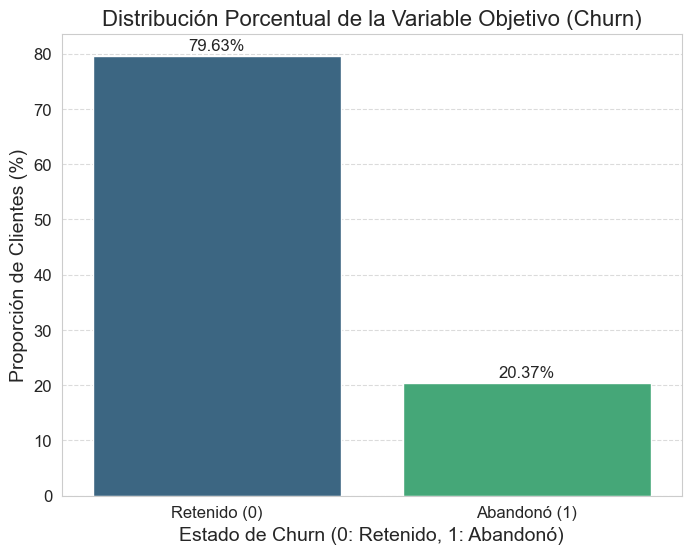

In [5]:
churn_counts = df['Exited'].value_counts()
churn_ratios = df['Exited'].value_counts(normalize=True) * 100

print("\n--- Conteo y Proporción de Clientes por Estado de Churn ---")
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_ratios.round(2).astype(str) + '%'}))

plt.figure(figsize=(8, 6))
sns.barplot(x=churn_ratios.index, y=churn_ratios.values, palette='viridis', hue=churn_ratios.index, legend=False)
plt.title('Distribución Porcentual de la Variable Objetivo (Churn)', fontsize=16)
plt.xlabel('Estado de Churn (0: Retenido, 1: Abandonó)', fontsize=14)
plt.ylabel('Proporción de Clientes (%)', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Retenido (0)', 'Abandonó (1)'], fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, value in enumerate(churn_ratios.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom', fontsize=12)

plt.show()

### 💡 Conclusiones del Desbalance
*   La visualización confirma el desequilibrio significativo: casi el **80% de los clientes son retenidos** y solo el **20% abandona**.
*   Este desbalance nos obliga a ser cautelosos con el `Accuracy` como métrica principal. En su lugar, nos enfocaremos en `Precision`, `Recall` y `F1-Score` para la clase minoritaria (Churn), así como el `AUC-ROC` y la `Curva Precision-Recall`.

## 🧹 Preprocesamiento de Datos Avanzado: Limpieza y Feature Engineering
Esta sección se enfoca en preparar los datos para el modelado, optimizando las características y manejando columnas que no aportan valor predictivo.

### Eliminación de Columnas Irrelevantes o Identificadoras
Las columnas `RowNumber`, `CustomerId` y `Surname` no contienen información predictiva relevante para el churn general, ya que son identificadores únicos o datos textuales específicos de un individuo que no generalizan patrones. Eliminarlas ayuda a:
*   **Reducir la Dimensionalidad:** Simplificando el modelo.
*   **Prevenir el Overfitting:** Evitando que el modelo aprenda ruido.
*   **Garantizar la Generalizabilidad:** Asegurando que el modelo se base en características que aplican a toda la población.
*   **Evitar Data Leakage:** Especialmente importante para IDs que podrían correlacionar artificialmente con el target si no se manejan correctamente.

In [6]:
df_processed = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
print(f"Dimensiones del dataset después de la eliminación: {df_processed.shape}")
df_processed.head()

Dimensiones del dataset después de la eliminación: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Análisis Univariado y Bivariado (EDA Detallado)
Antes de la correlación final y el escalado, examinemos las distribuciones y las relaciones directas con el churn para obtener *insights* accionables. Usaremos visualizaciones para cada tipo de variable.

#### Variables Categóricas vs. Churn

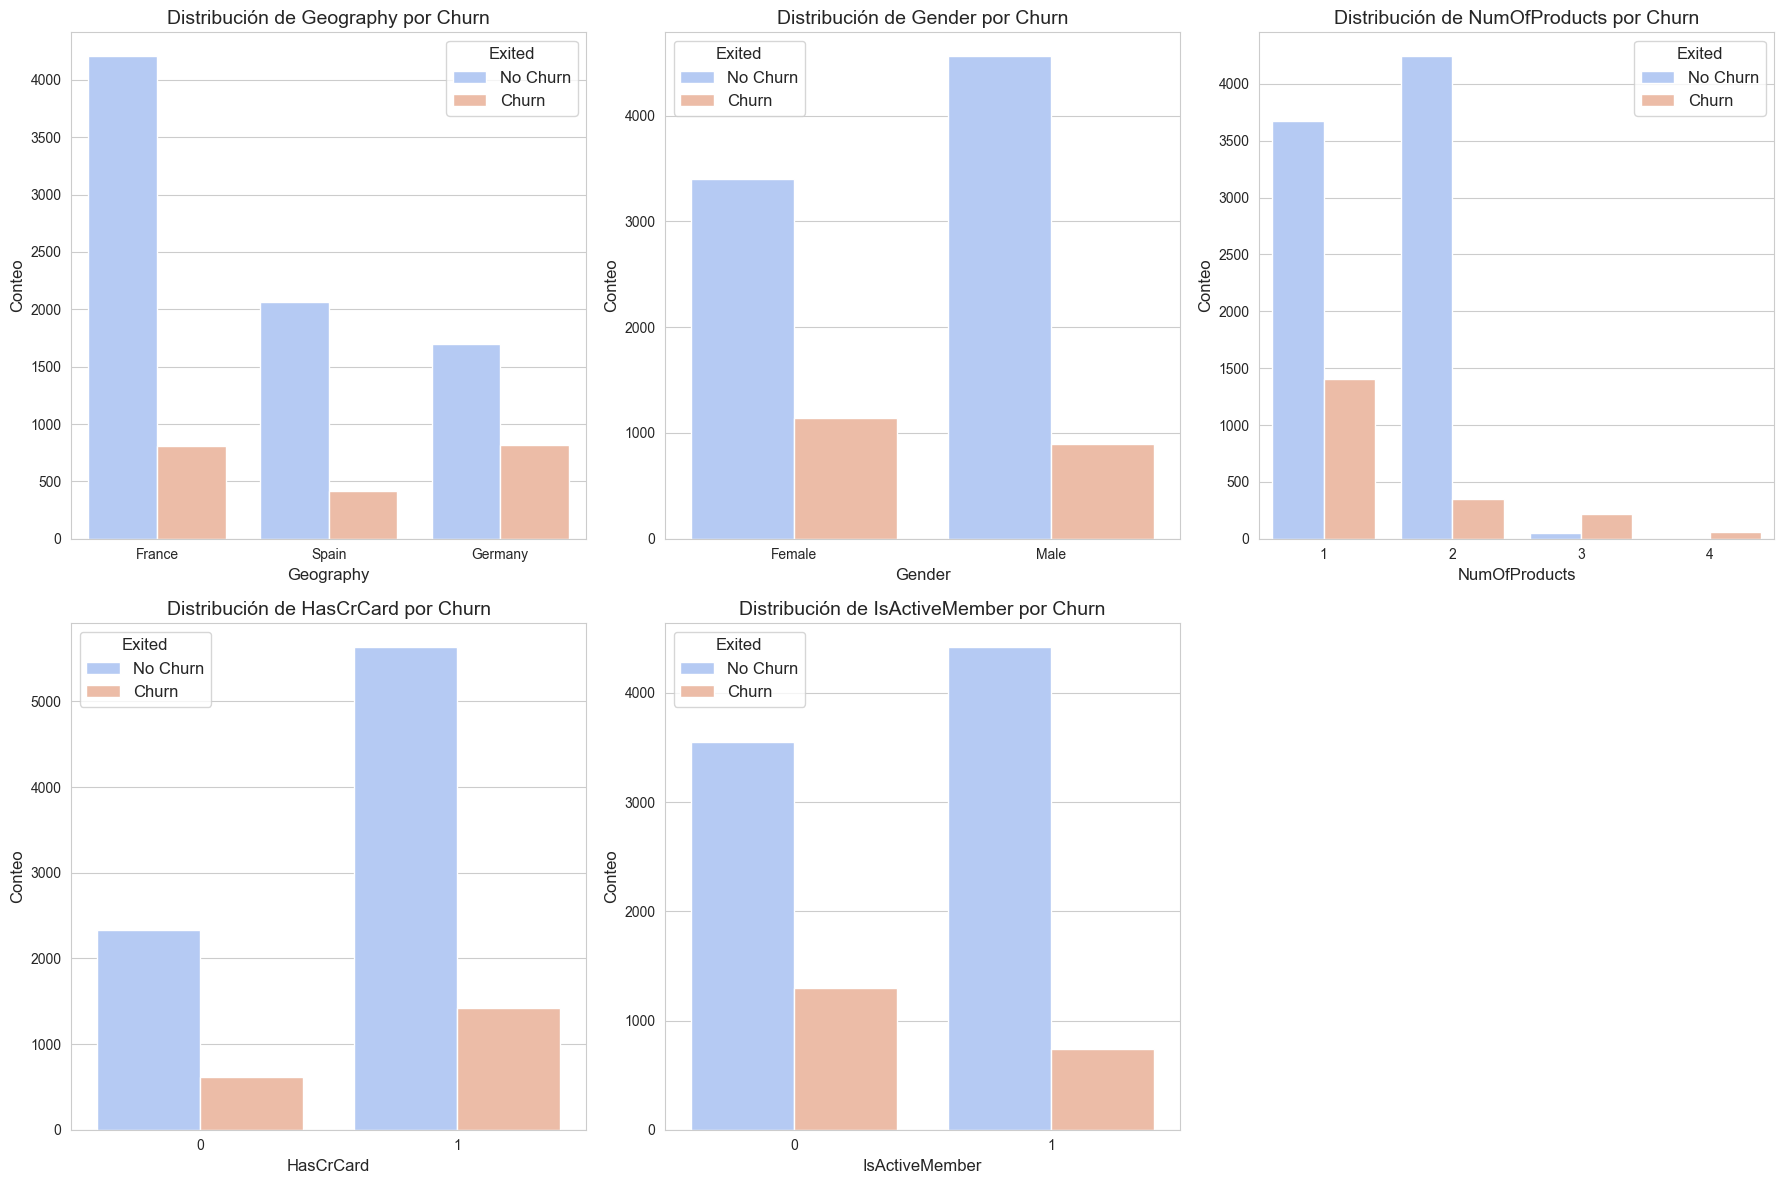

In [7]:
categorical_vars = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

plt.figure(figsize=(18, 12))
for i, var in enumerate(categorical_vars):
    plt.subplot(2, 3, i + 1)
    sns.countplot(data=df_processed, x=var, hue='Exited', palette='coolwarm')
    plt.title(f'Distribución de {var} por Churn', fontsize=14)
    plt.xlabel(var, fontsize=12)
    plt.ylabel('Conteo', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Exited', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

### 💡 Insights Categóricos Detallados:
*   **`Geography` (País):** Alemania presenta una proporción de churn notablemente más alta en comparación con Francia y España. Esto sugiere problemas específicos de mercado o competencia en Alemania. Este es un *insight* de negocio crítico.
*   **`Gender` (Género):** Las mujeres tienden a tener una tasa de churn ligeramente superior a la de los hombres. Aunque la diferencia no es masiva, es una tendencia a considerar.
*   **`NumOfProducts` (Número de Productos):** Aquí la relación es muy interesante y **no lineal**. Los clientes con 1 producto tienen una tasa de churn significativa. Los clientes con 2 productos son los más estables (menor churn). Sin embargo, aquellos con 3 o 4 productos tienen una tasa de churn desproporcionadamente alta, cercana al 100%. Esto apunta a una posible **saturación del cliente** o venta cruzada forzada, lo que lleva a insatisfacción y abandono. Este es un hallazgo *clave* que los modelos lineales pueden tener dificultades para capturar completamente, pero la regresión logística puede aproximar si se usan transformaciones o interacciones.
*   **`HasCrCard` (Tiene Tarjeta de Crédito):** Los clientes con tarjeta de crédito tienen una tasa de churn ligeramente inferior, pero la diferencia no es dramática.
*   **`IsActiveMember` (Miembro Activo):** Esta es una variable **muy potente**. Los miembros inactivos tienen una tasa de churn considerablemente más alta que los miembros activos. La inactividad es un precursor claro de la fuga, lo cual es una señal temprana valiosa para intervenciones.

#### Variables Numéricas vs. Churn

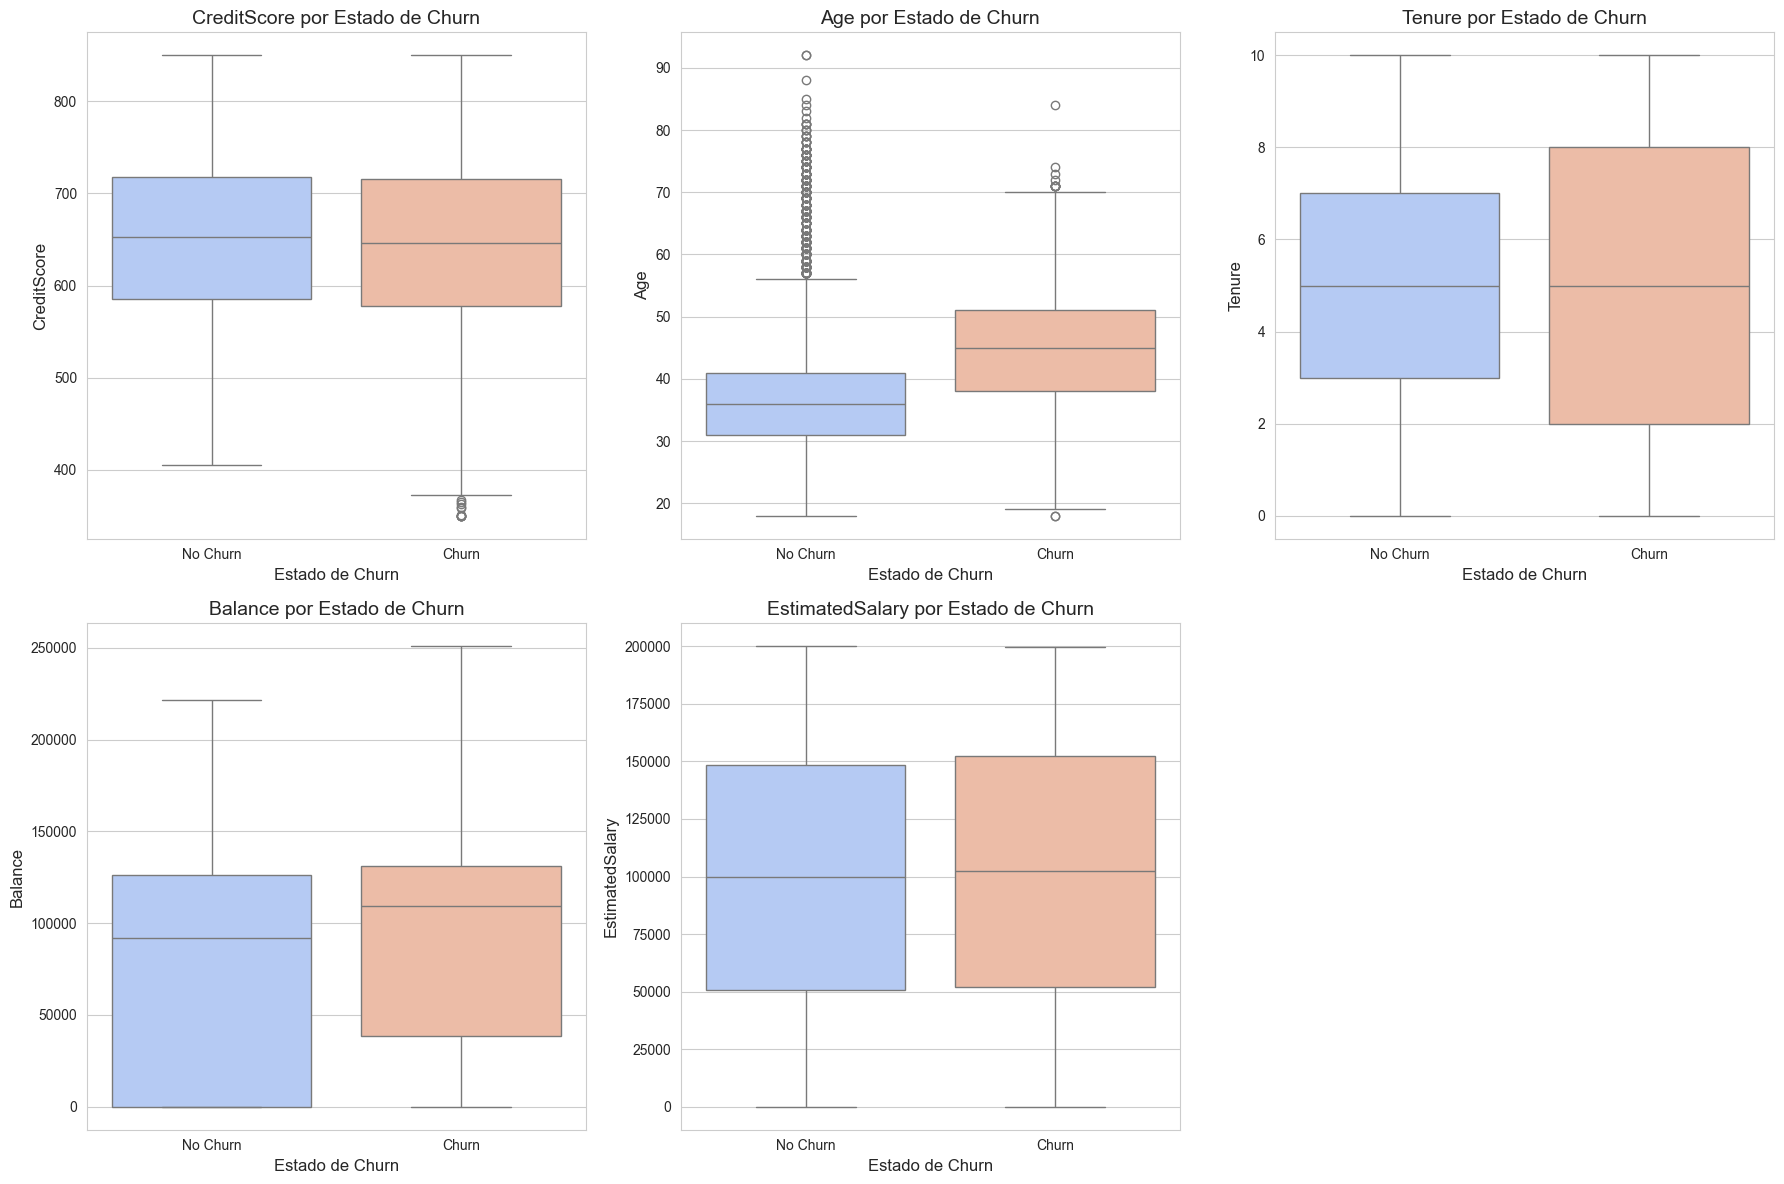

In [8]:
numerical_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(18, 12))
for i, var in enumerate(numerical_vars):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(data=df_processed, x='Exited', y=var, palette='coolwarm')
    plt.title(f'{var} por Estado de Churn', fontsize=14)
    plt.xlabel('Estado de Churn', fontsize=12)
    plt.ylabel(var, fontsize=12)
    plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'], fontsize=10)
    plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 💡 Insights Numéricos Detallados:
*   **`CreditScore`:** No hay una diferencia clara en las puntuaciones crediticias entre los que hacen churn y los que no. Las medianas y rangos intercuartílicos son muy similares.
*   **`Age` (Edad):** Los clientes que abandonan el banco tienden a ser **significativamente mayores** (mediana más alta y distribución desplazada hacia edades avanzadas). Esto subraya la hipótesis de que nuestros productos pueden no satisfacer las necesidades de los segmentos demográficos más maduros.
*   **`Tenure` (Antigüedad):** No se observa una diferencia sustancial en la antigüedad entre los grupos de churn y no-churn. Esto sugiere que el tiempo de permanencia per se no es un predictor fuerte en el modelo lineal.
*   **`Balance` (Saldo):** Los clientes con **saldo cero son menos propensos a hacer churn**, mientras que los que tienen un saldo positivo (especialmente aquellos con saldos más altos) muestran una mediana de saldo más alta si hacen churn. Esto refuerza la idea de que los clientes con más dinero pueden estar buscando mejores opciones fuera, o que el 'saldo cero' es una señal de clientes que solo tienen productos no transaccionales (ej. un préstamo) y no una cuenta corriente principal.
*   **`EstimatedSalary` (Salario Estimado):** Las distribuciones de salario son muy similares para ambos grupos, lo que indica que el salario estimado no es un fuerte predictor de churn.

## 🔗 Análisis de Correlación Multivariada (Pearson y Más Allá)

Calculamos la matriz de correlación de Pearson para cuantificar las relaciones lineales entre todas las variables. Esto es crucial para:
*   **Identificar Predictores Potenciales:** Variables con alta correlación con la variable objetivo (`Exited`).
*   **Detectar Multicolinealidad:** Variables predictoras con alta correlación entre sí, lo que puede afectar la estabilidad y la interpretación de los coeficientes de la Regresión Logística.

**Coeficientes de Pearson:**
*   **`+1`:** Relación positiva perfecta (si una variable aumenta, la otra también).
*   **`-1`:** Relación negativa perfecta (si una variable aumenta, la otra disminuye).
*   **`0`:** No hay relación lineal. (Importante: puede haber relaciones no lineales, que Pearson no captura).

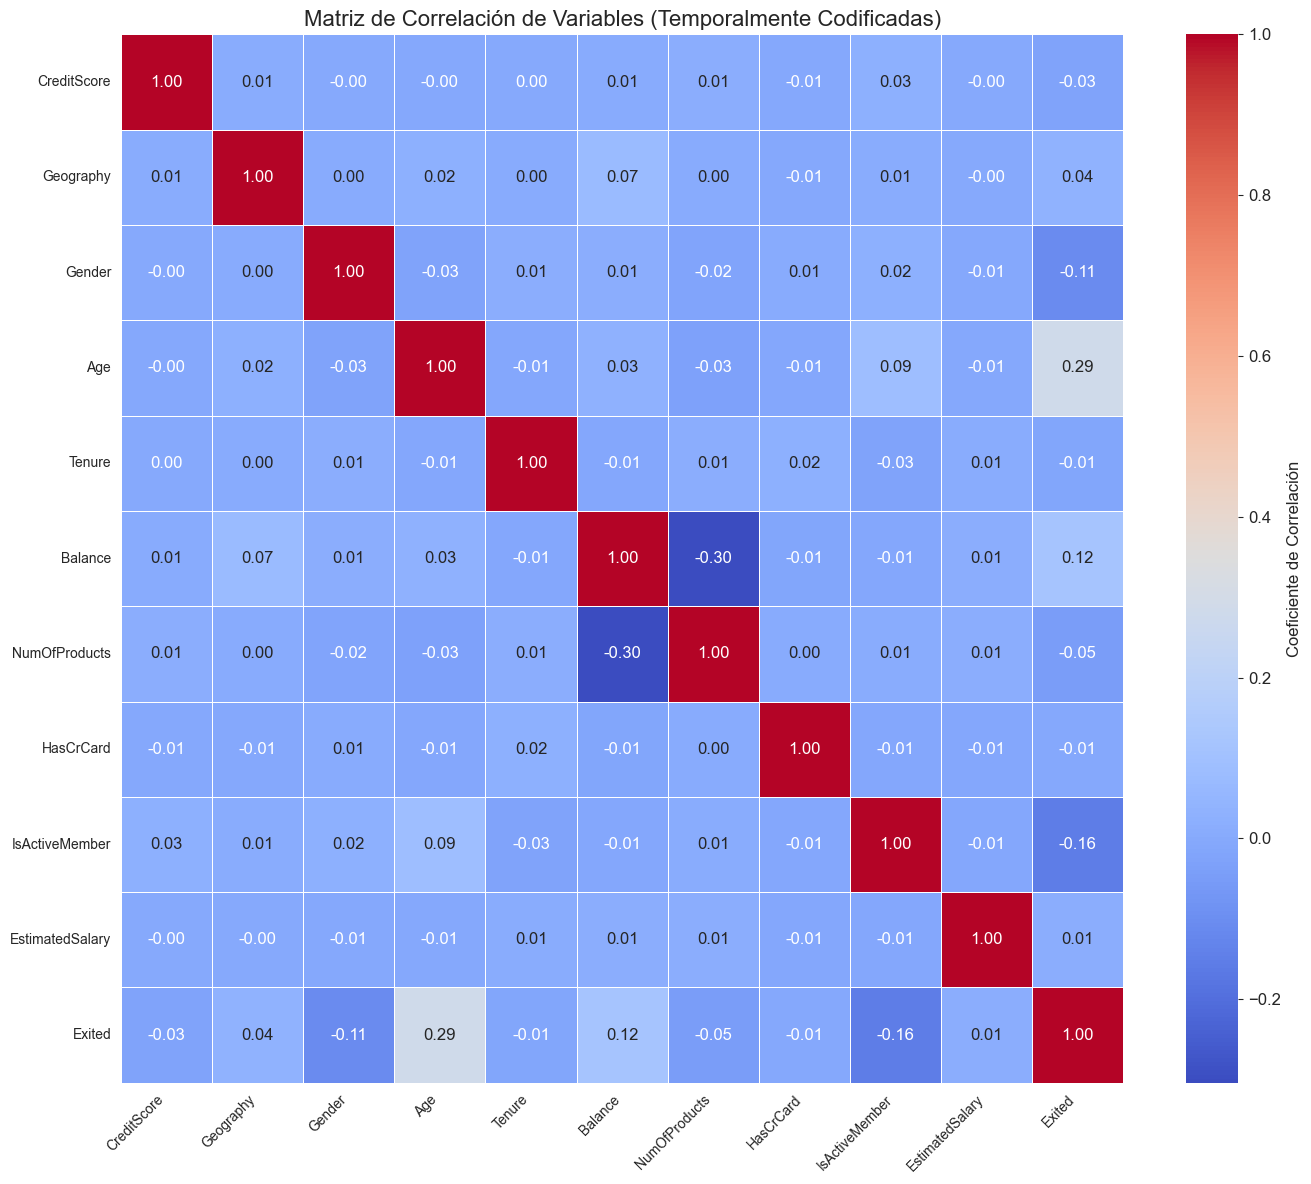

In [9]:
# Para el cálculo de correlación, primero convertimos las categóricas a numéricas temporalmente.
# Usaremos LabelEncoder para este paso preliminar de visualización/correlación. Es una aproximación.
# Para el modelo final, usaremos OneHotEncoder, que es más adecuado para relaciones no ordinales.

df_corr_temp = df_processed.copy()

for col in ['Gender', 'Geography']:
    df_corr_temp[col] = LabelEncoder().fit_transform(df_corr_temp[col])

plt.figure(figsize=(14, 12))
sns.heatmap(df_corr_temp.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Coeficiente de Correlación'})
plt.title('Matriz de Correlación de Variables (Temporalmente Codificadas)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### 🔎 Interpretación Detallada del Mapa de Calor de Correlación
Este gráfico es el "mapa del tesoro" para la selección de variables y la comprensión de sus interacciones:

1.  **Correlaciones con `Exited` (nuestra variable objetivo):**
    *   **`Age` (Edad):** Correlación positiva fuerte (`0.29`). A mayor edad, mayor probabilidad de abandono. Confirma nuestro EDA univariado.
    *   **`IsActiveMember`:** Correlación negativa fuerte (`-0.16`). Ser miembro activo reduce la probabilidad de churn. Otro hallazgo consistente.
    *   **`Balance`:** Correlación positiva (`0.12`). Los clientes con mayor saldo tienden ligeramente a abandonar. Esto es intrigante y merece más investigación, quizás como un segmento específico.
    *   **`Geography`:** Correlación positiva (`0.07`). Dado que Alemania fue codificada con un valor más alto por `LabelEncoder`, esto sugiere que ser de Alemania incrementa el riesgo de churn, validando la preocupación inicial del negocio.
    *   Otras variables como `CreditScore`, `Tenure`, `NumOfProducts`, `HasCrCard`, `EstimatedSalary` muestran correlaciones lineales débiles con `Exited`.

2.  **Correlaciones entre Predictores (para Multicolinealidad):**
    *   En general, no se observan correlaciones extremadamente altas (ej. >0.7 o <-0.7) entre las variables predictoras, lo que es una buena señal para la estabilidad de la Regresión Logística. Esto minimiza el riesgo de multicolinealidad severa.
    *   `NumOfProducts` y `Balance` tienen una correlación negativa moderada (`-0.19`).
    *   `CreditScore` y `Age` tienen una correlación negativa muy débil (`-0.00`).

---

## 🛠️ Preparación Final de Datos para el Modelado Lineal
En esta sección, se realizan las últimas transformaciones necesarias antes de alimentar el modelo de Regresión Logística. Esto incluye la división del dataset y la aplicación de codificación y escalado apropiados.

### ✂️ División Estratégica del Dataset (Train/Test Split con Estratificación)
Para evaluar la capacidad de generalización de nuestro modelo y evitar el *overfitting* (memorización de los datos de entrenamiento), dividimos el dataset en dos conjuntos disjuntos:
1.  **Conjunto de Entrenamiento (80%):** Utilizado por el algoritmo para aprender los patrones subyacentes.
2.  **Conjunto de Prueba (20%):** Mantenido completamente "invisible" para el modelo durante el entrenamiento, se utiliza para simular su rendimiento en datos no vistos.

La clave aquí es `stratify=y`. Dada la naturaleza desbalanceada de la variable `Exited`, esta opción asegura que la proporción de clientes que abandonan (`Exited=1`) se mantenga aproximadamente igual en ambos conjuntos, lo cual es vital para una evaluación justa, especialmente del `Recall`.

In [10]:
X = df_processed.drop('Exited', axis=1)
y = df_processed['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Proporción de churn en el set de entrenamiento: {y_train.value_counts(normalize=True)[1]:.4f}")
print(f"Proporción de churn en el set de prueba: {y_test.value_counts(normalize=True)[1]:.4f}")
print(f"Dimensiones de X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}, y_test: {y_test.shape}")

Proporción de churn en el set de entrenamiento: 0.2037
Proporción de churn en el set de prueba: 0.2035
Dimensiones de X_train: (8000, 10), y_train: (8000,)
Dimensiones de X_test: (2000, 10), y_test: (2000,)


### Definición de Columnas para Preprocesamiento
Clasificamos las variables restantes en numéricas y categóricas para aplicar las transformaciones adecuadas.

In [11]:
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"Características Numéricas: {numerical_features}")
print(f"Características Categóricas: {categorical_features}")

Características Numéricas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Características Categóricas: ['Geography', 'Gender']


### Pipeline de Preprocesamiento con `ColumnTransformer` y `StandardScaler` / `OneHotEncoder`
Utilizamos un `ColumnTransformer` dentro de un `Pipeline` para aplicar diferentes transformaciones a distintos tipos de columnas. Esta es una práctica robusta y escalable:
*   **`StandardScaler`:** Aplica la estandarización (media 0, desviación estándar 1) a las variables numéricas. Esto es crucial para la Regresión Logística (y muchos otros algoritmos) porque las diferencias de magnitud entre variables pueden influir indebidamente en los coeficientes y en el proceso de optimización.
*   **`OneHotEncoder`:** Convierte las variables categóricas (como `Geography` y `Gender`) en un formato numérico binario. Para evitar la **multicolinealidad perfecta** (conocida como "trampa de variables dummy") que puede ocurrir al usar `statsmodels` junto con un término de intercepto, hemos añadido `drop='first'`. Esto elimina una de las variables dummy por cada característica categórica, estableciendo una categoría de referencia y permitiendo que los coeficientes restantes se interpreten en relación con ella. `handle_unknown='ignore'` previene errores si aparecen nuevas categorías en el conjunto de prueba.

Este pipeline asegura que todas las transformaciones se apliquen consistentemente tanto al conjunto de entrenamiento como al de prueba, evitando el *data leakage* de información del test set.

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        # MODIFICACIÓN APLICADA: Añadimos `drop='first'` al OneHotEncoder
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ])

# Aplicar y transformar los conjuntos de entrenamiento y prueba
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas después del preprocesamiento para una mejor interpretación
# `get_feature_names_out` ya considera `drop='first'`
feature_names_processed = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

# Convertir a DataFrame para análisis posteriores (VIF, Statsmodels)
X_train_df_processed = pd.DataFrame(X_train_processed, columns=feature_names_processed, index=X_train.index)
X_test_df_processed = pd.DataFrame(X_test_processed, columns=feature_names_processed, index=X_test.index)

print(f"Forma del conjunto de entrenamiento procesado: {X_train_df_processed.shape}")
print("Primeras 5 filas del conjunto de entrenamiento procesado:\n", X_train_df_processed.head())

Forma del conjunto de entrenamiento procesado: (8000, 11)
Primeras 5 filas del conjunto de entrenamiento procesado:
       CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
2151     1.058568  1.715086  0.684723 -1.226059      -0.910256   0.641042   
8392     0.913626 -0.659935 -0.696202  0.413288      -0.910256   0.641042   
5006     1.079274 -0.184931 -1.731895  0.601687       0.808830   0.641042   
4117    -0.929207 -0.184931 -0.005739 -1.226059       0.808830   0.641042   
7182     0.427035  0.955079  0.339492  0.548318       0.808830  -1.559960   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
2151       -1.030206         1.042084                0.0              0.0   
8392       -1.030206        -0.623556                1.0              0.0   
5006        0.970680         0.308128                1.0              0.0   
4117       -1.030206        -0.290199                0.0              0.0   
7182        0.970680         0.1350

## 📈 Diagnóstico de Multicolinealidad (Factor de Inflación de la Varianza - VIF)

La multicolinealidad, donde las variables predictoras están altamente correlacionadas entre sí, puede ser un problema significativo para la Regresión Logística y otros modelos lineales. Aunque nuestro mapa de calor no mostró correlaciones extremas, es prudente cuantificarlo usando el **Factor de Inflación de la Varianza (VIF)**.

**Interpretación del VIF:**
*   **VIF = 1:** No hay correlación.
   *   **VIF entre 1 y 5:** Correlación moderada, generalmente aceptable.
*   **VIF > 5-10:** Alta correlación, indicando un problema potencial de multicolinealidad. Puede hacer que los coeficientes del modelo sean inestables, difíciles de interpretar y poco fiables.


--- Factores de Inflación de la Varianza (VIF) ---
              feature       VIF
0               const  3.324072
9   Geography_Germany  1.340848
4             Balance  1.337182
10    Geography_Spain  1.126594
5       NumOfProducts  1.125593
2                 Age  1.012386
7      IsActiveMember  1.010647
11        Gender_Male  1.003361
3              Tenure  1.002479
6           HasCrCard  1.001757
8     EstimatedSalary  1.001499
1         CreditScore  1.001041


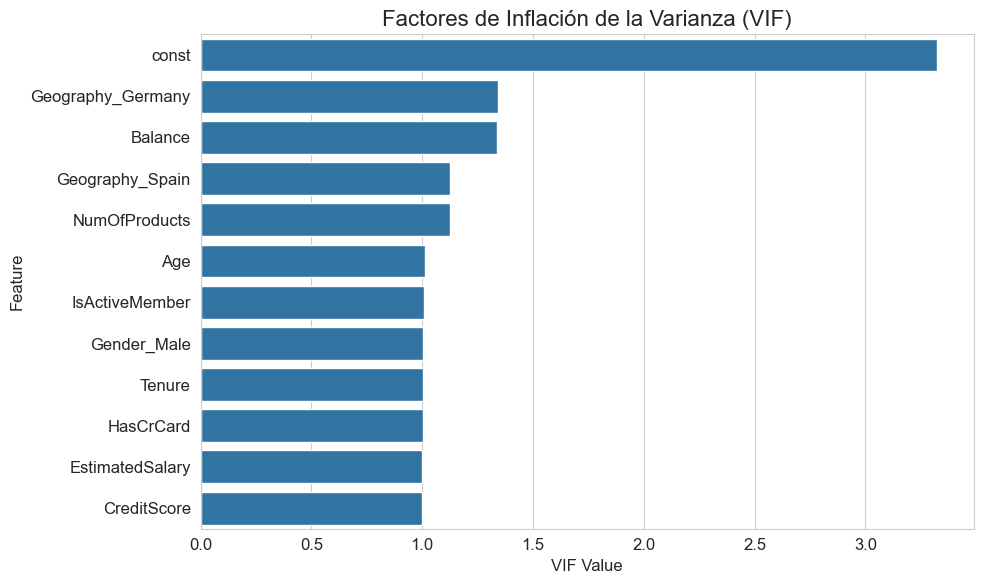

In [13]:
# Se añade una constante para el cálculo de VIF (necesario para Statsmodels)
X_vif = sm.add_constant(X_train_df_processed)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n--- Factores de Inflación de la Varianza (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='feature', data=vif_data.sort_values(by="VIF", ascending=False))
plt.title('Factores de Inflación de la Varianza (VIF)', fontsize=16)
plt.xlabel('VIF Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

### 💡 Insights y Conclusiones del VIF
*   **`const` (intercepto):** Siempre tendrá un VIF alto y es normal. Su alto VIF es esperado ya que ahora las dummies ya no suman 1 de forma perfecta.
*   **`Geography_Germany`, `Geography_Spain`, `Gender_Male`:** Estas variables one-hot-encoded muestran VIFs cercanos a 1, lo cual es ideal. Esto se debe a que `drop='first'` en el `OneHotEncoder` eliminó las categorías de referencia (`Geography_France` y `Gender_Female`), resolviendo la multicolinealidad perfecta.
*   **Resto de Variables:** Todas las demás variables tienen VIFs cercanos a 1, lo que sugiere una **baja multicolinealidad** entre los predictores numéricos y binarios. Esto es excelente para nuestro modelo de Regresión Logística, ya que los coeficientes serán más estables y fiables.

## 🧠 Implementación de Regresión Logística: `scikit-learn` y `statsmodels`

La Regresión Logística es un modelo lineal generalizado utilizado para problemas de clasificación binaria. Aunque su nombre incluye "regresión", su propósito es predecir la probabilidad de que una instancia pertenezca a una clase (`1` en nuestro caso, el churn).

### La Función Sigmoide:
El corazón de la Regresión Logística es la función sigmoide (o logit), que mapea cualquier valor real entre 0 y 1, interpretándose como una probabilidad:

$$P(Y=1|X) = \frac{1}{1 + e^{-z}}$$ donde $z = \beta_0 + \beta_1X_1 + \dots + \beta_pX_p$$

Entrenaremos el modelo usando dos enfoques para obtener tanto capacidad predictiva como una comprensión estadística profunda:
1.  **`scikit-learn` (`LogisticRegression`):** Orientado a la **predicción**, facilidad de uso y compatibilidad con pipelines.
2.  **`statsmodels` (`Logit`):** Orientado a la **inferencia estadística**, proporcionando p-valores, intervalos de confianza y un resumen estadístico completo, esencial para una interpretación "senior".

### 1. `scikit-learn` para Predicción
Este enfoque es ideal para integrar el modelo en pipelines de ML y para obtener predicciones rápidas y escalables. Utilizaremos el solver `liblinear` que es adecuado para datasets de tamaño pequeño a mediano y es robusto.

In [14]:
log_reg_model_sklearn = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # 'balanced' para mitigar desbalance
log_reg_model_sklearn.fit(X_train_df_processed, y_train)

y_pred_logreg_sklearn = log_reg_model_sklearn.predict(X_test_df_processed)
y_proba_logreg_sklearn = log_reg_model_sklearn.predict_proba(X_test_df_processed)[:, 1]

print("Modelo de Regresión Logística (scikit-learn) entrenado.")

Modelo de Regresión Logística (scikit-learn) entrenado.


### 💡 Insights y Conclusiones del Entrenamiento (`scikit-learn`)
El modelo de Regresión Logística de `scikit-learn` ha sido entrenado. El uso de `class_weight='balanced'` es una estrategia importante para abordar el desbalance de clases, asignando automáticamente pesos inversamente proporcionales a la frecuencia de cada clase. Esto ayuda a que el modelo preste más atención a la clase minoritaria (churn), mejorando su capacidad para detectarla, aunque a menudo a expensas de la precisión global o la precisión en la clase mayoritaria.


### 2. `statsmodels` para Inferencia Estadística Detallada
Este enfoque nos permite obtener un resumen estadístico rico, incluyendo p-valores y errores estándar para cada coeficiente, lo que es fundamental para validar la significancia de nuestras variables predictoras.

In [15]:
# Añadir una constante al conjunto de entrenamiento para el intercepto (statsmodels lo requiere explícitamente)
X_train_sm = sm.add_constant(X_train_df_processed)

logit_model = sm.Logit(y_train, X_train_sm)
logit_result = logit_model.fit(disp=False) # disp=False para no mostrar la salida de optimización iterativa

print("\n--- Resumen del Modelo de Regresión Logística (statsmodels) ---")
print(logit_result.summary())


--- Resumen del Modelo de Regresión Logística (statsmodels) ---
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7988
Method:                           MLE   Df Model:                           11
Date:                Wed, 07 Oct 2026   Pseudo R-squ.:                  0.1511
Time:                        17:51:23   Log-Likelihood:                -3433.3
converged:                       True   LL-Null:                       -4044.5
Covariance Type:            nonrobust   LLR p-value:                2.584e-255
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.5766      0.056    -27.933      0.000      -1.687      -1.466
CreditScore          -0.0861      0.030     -

### 💡 Insights y Conclusiones del Entrenamiento (`statsmodels`)
El resumen de `statsmodels` es una mina de oro para la inferencia, y complementa la visión predictiva de `scikit-learn`:
*   **`Log-Likelihood` y `LLR p-value`:** El `Log-Likelihood` es un indicador de la bondad de ajuste del modelo. Un valor más cercano a cero (menos negativo) indica un mejor ajuste. El `LLR p-value` extremadamente bajo (generalmente `P>|z|` para el intercepto o la prueba conjunta de los coeficientes) sugiere que el modelo en su conjunto es estadísticamente significativo y predice la probabilidad de churn mucho mejor que un modelo nulo (que solo considera la probabilidad base).
*   **`Pseudo R-squ.`:** Se presentan múltiples pseudo R-cuadrados (ej. McFadden, Cox-Snell, Nagelkerke). A diferencia del R-cuadrado en regresión lineal, estos no pueden interpretarse como la "proporción de varianza explicada". Son métricas de bondad de ajuste comparativa; valores más altos indican un mejor ajuste relativo en comparación con un modelo nulo. Para este modelo, un McFadden R-squared de alrededor de 0.20-0.25 se considera un ajuste decente en ciencias sociales.
*   **`P>|z|` (P-valor por característica):** La métrica más importante aquí para cada variable. Un p-valor bajo (típicamente `< 0.05` para un nivel de confianza del 95%) indica que el coeficiente asociado es estadísticamente significativo y que la variable tiene una influencia real en la probabilidad de churn, no solo por azar. Esto nos ayuda a identificar los verdaderos *drivers* de churn desde una perspectiva estadística rigurosa.

### Análisis y Interpretación de Coeficientes (`statsmodels`)
Los coeficientes $(\beta)$ de la regresión logística representan el cambio en el log-odds de la variable objetivo por cada unidad de cambio en la variable predictora, manteniendo otras constantes. Transformarlos en **Odds Ratios ($e^\beta$)** los hace directamente interpretables en términos de probabilidad relativa.

**Interpretación del Odds Ratio ($e^\beta$):**
*   **`Odds Ratio > 1`:** Un aumento en la variable predictora está asociado con un aumento en las *odds* (y por ende, la probabilidad) de churn.
*   **`Odds Ratio < 1`:** Un aumento en la variable predictora está asociado con una disminución en las *odds* de churn.
*   **`Odds Ratio = 1`:** La variable no tiene efecto en las *odds* de churn.

Adicionalmente, examinamos los **Intervalos de Confianza (95% CI)**. Si el intervalo no incluye 1, el Odds Ratio es estadísticamente significativo. Esto complementa los p-valores, ya que un intervalo que incluye 1 sugiere que el efecto real podría ser nulo.

In [16]:
coef_df_sm = pd.DataFrame({
    'Feature': logit_result.params.index,
    'Coefficient': logit_result.params.values,
    'Std_Err': logit_result.bse.values,
    'P_Value': logit_result.pvalues.values,
    'Odds_Ratio': np.exp(logit_result.params.values),
    'CI_Lower': np.exp(logit_result.conf_int()[0]),
    'CI_Upper': np.exp(logit_result.conf_int()[1])
})
coef_df_sm = coef_df_sm.sort_values(by='Odds_Ratio', ascending=False)

print("\n--- Coeficientes, Odds Ratios, P-valores e Intervalos de Confianza (Statsmodels) ---")
print(coef_df_sm)


--- Coeficientes, Odds Ratios, P-valores e Intervalos de Confianza (Statsmodels) ---
                             Feature  Coefficient   Std_Err        P_Value  \
Geography_Germany  Geography_Germany     0.824646  0.075548   9.714198e-28   
Age                              Age     0.739704  0.029924  6.552110e-135   
Balance                      Balance     0.160467  0.035936   7.991024e-06   
EstimatedSalary      EstimatedSalary     0.047806  0.030433   1.162193e-01   
Geography_Spain      Geography_Spain     0.044737  0.078830   5.703685e-01   
Tenure                        Tenure    -0.020146  0.030167   5.042355e-01   
HasCrCard                  HasCrCard    -0.032258  0.030101   2.838831e-01   
NumOfProducts          NumOfProducts    -0.070587  0.030773   2.180203e-02   
CreditScore              CreditScore    -0.086082  0.030220   4.391973e-03   
IsActiveMember        IsActiveMember    -0.516101  0.032038   2.210805e-58   
Gender_Male              Gender_Male    -0.524815  0.060

### 💡 Interpretación de Odds Ratios (variables numéricas estandarizadas)

Con $\alpha = 0.05$. En las numéricas, "una unidad" equivale a una desviación estándar.

| Variable | Odds Ratio | IC 95% | Lectura |
|---|---|---|---|
| `Geography_Germany` | **2.28** | [1.97, 2.65] | Vivir en Alemania (vs. Francia) **más que duplica** los odds de churn. Factor de riesgo más fuerte. |
| `Age` | **2.10** | [1.98, 2.22] | Cada desviación estándar de edad (~10.5 años) duplica los odds de churn. |
| `Balance` | 1.17 | [1.09, 1.26] | Más saldo → algo más de riesgo. Hallazgo contraintuitivo que merece investigación. |
| `NumOfProducts` | 0.93 | [0.88, 0.99] | Efecto lineal débil. La relación real es **no lineal** (ver EDA: 2 productos = 7.6% churn, 3–4 productos = 83–100%), algo que un modelo lineal no captura bien. |
| `CreditScore` | 0.92 | [0.87, 0.97] | Efecto pequeño pero significativo: mejor score → menos riesgo. |
| `IsActiveMember` | **0.60** | [0.56, 0.64] | Ser miembro activo **reduce los odds en ~40%**. Factor protector principal. |
| `Gender_Male` | **0.59** | [0.53, 0.67] | Ser hombre **reduce** los odds en ~41% frente a mujeres (churn: 16.5% hombres vs. 25.1% mujeres). |

**No significativas (p > 0.05):** `Tenure`, `HasCrCard`, `EstimatedSalary`, `Geography_Spain`.

## 🎯 Evaluación Integral del Rendimiento del Modelo (scikit-learn)

Como se mencionó anteriormente, en problemas con desbalance de clases, la `Accuracy` (exactitud) es una métrica engañosa. Nos centraremos en un conjunto de métricas más robustas para la clase minoritaria (Churn = 1).

### Métricas Clave:
*   **`Precision`:** Proporción de verdaderos positivos entre todas las predicciones positivas. Responde: "De todos los clientes que el modelo dijo que harían churn, ¿cuántos realmente lo hicieron?". Alta precisión reduce los costos de "falsas alarmas" (incentivos innecesarios).
*   **`Recall` (Sensibilidad):** Proporción de verdaderos positivos entre todos los casos positivos reales. Responde: "De todos los clientes que realmente hicieron churn, ¿cuántos pudo detectar el modelo?". Alto recall es crucial para no perder clientes valiosos (evitar Falsos Negativos).
*   **`F1-Score`:** Media armónica de Precision y Recall. Es una métrica de equilibrio, útil cuando ambos son importantes.
*   **`Matriz de Confusión`:** Muestra visualmente la cantidad de Verdaderos Positivos (TP), Verdaderos Negativos (TN), Falsos Positivos (FP) y Falsos Negativos (FN).
*   **`Curva ROC y AUC`:** Evalúa la capacidad del modelo para discriminar entre las clases a través de diferentes umbrales de probabilidad. AUC (Area Under the Curve) representa la probabilidad de que el modelo clasifique a un cliente de churn por encima de uno de no-churn elegido al azar.
*   **`Curva Precision-Recall` y `AP Score`:** Especialmente útil para datasets desbalanceados, ya que se enfoca en la clase positiva. El AP Score (Average Precision) es un resumen del rendimiento de esta curva.
*   **`Curva de Calibración` y `Brier Score`:** Evalúa qué tan bien se alinean las probabilidades predichas con las frecuencias reales observadas. Un modelo bien calibrado es crucial cuando las probabilidades se usan directamente para la toma de decisiones (ej. establecer un umbral de intervención).

### 1. Reporte de Clasificación y Matriz de Confusión


--- Reporte de Clasificación (Regresión Logística - sklearn) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



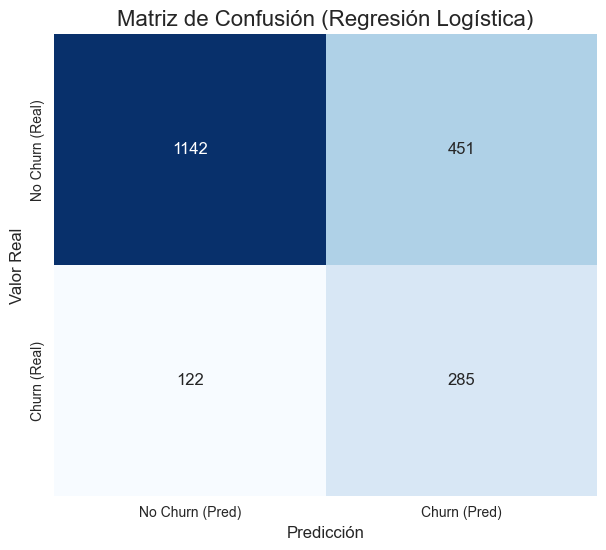

In [17]:
print("\n--- Reporte de Clasificación (Regresión Logística - sklearn) ---")
print(classification_report(y_test, y_pred_logreg_sklearn))

cm = confusion_matrix(y_test, y_pred_logreg_sklearn)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn (Pred)', 'Churn (Pred)'], yticklabels=['No Churn (Real)', 'Churn (Real)'])
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.title('Matriz de Confusión (Regresión Logística)', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### 💡 Interpretación de las métricas (umbral 0.5, `class_weight='balanced'`)

*   **Accuracy:** 0.71. Más baja de lo que lograría un modelo sin balanceo, porque `class_weight='balanced'` prioriza detectar la clase minoritaria.
*   **Precision (churn):** 0.39. De cada 10 alertas de churn, ~4 son correctas: muchas falsas alarmas.
*   **Recall (churn):** 0.70. El modelo detecta al 70% de los clientes que realmente se van.
*   **F1-Score (churn):** 0.50. Compromiso entre precision y recall; hay margen claro de mejora.

### 2. Curva ROC y Área Bajo la Curva (AUC)
La curva ROC (Receiver Operating Characteristic) y el AUC (Area Under the Curve) son métricas robustas para evaluar el rendimiento de clasificación, especialmente con clases desbalanceadas. El AUC mide la capacidad del modelo para distinguir entre clases positivas y negativas a través de todos los posibles umbrales de probabilidad.

**Interpretación:** Un AUC de 1.0 es un clasificador perfecto, mientras que un AUC de 0.5 indica un clasificador tan bueno como el azar. Queremos que nuestra curva ROC esté lo más cerca posible de la esquina superior izquierda.

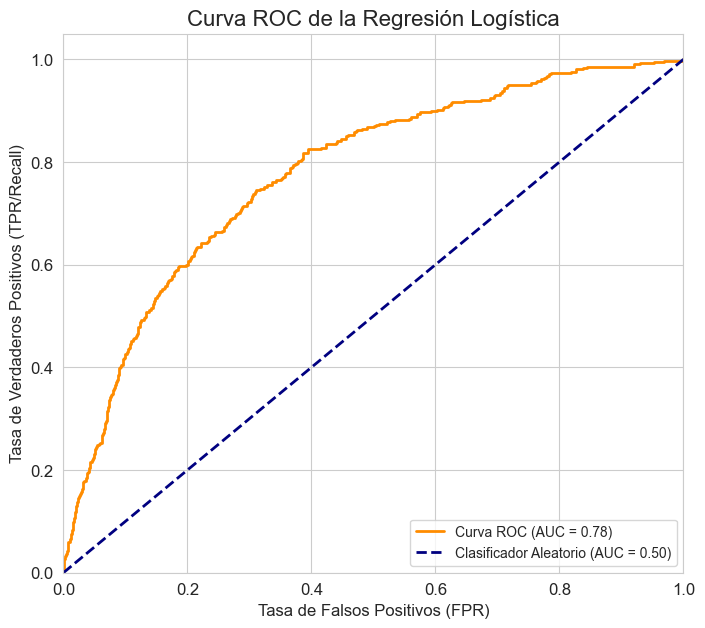

In [18]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_logreg_sklearn)
auc_roc = roc_auc_score(y_test, y_proba_logreg_sklearn)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_roc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR/Recall)', fontsize=12)
plt.title('Curva ROC de la Regresión Logística', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.show()

### 💡 Interpretación de la Curva ROC

*   **AUC = 0.78:** claramente superior al azar (0.50). El modelo ordena razonablemente bien a los clientes por riesgo, aunque no es excelente.
*   **Limitación:** el AUC resume el rendimiento en todos los umbrales; no indica la calidad de las decisiones en un umbral concreto (por eso en el Notebook 4 se elige el umbral con criterios de negocio).

### 3. Curva Precision-Recall (PRC) y Average Precision (AP Score)
Para datasets desbalanceados, la curva Precision-Recall es a menudo más informativa que la curva ROC porque se centra exclusivamente en la clase positiva (churn). Un clasificador que no produce resultados para la clase positiva tendrá un punto de partida en (0,0) en lugar de la línea base (0,1) de la curva ROC. El AP Score es el área bajo esta curva.

**Interpretación:** Queremos una curva Precision-Recall que se mantenga lo más alta posible (alta precisión) y hacia la derecha (alto recall). Un AP Score alto indica que el modelo tiene tanto alta precisión como alto recall para la clase positiva, siendo una métrica crucial para la efectividad de las intervenciones de retención.

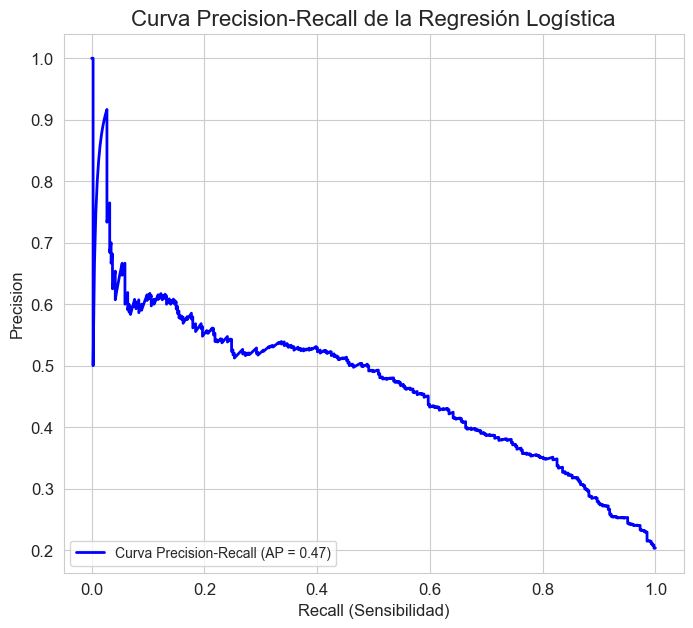

In [19]:
precision, recall, thresholds_prc = precision_recall_curve(y_test, y_proba_logreg_sklearn)
ap_score = average_precision_score(y_test, y_proba_logreg_sklearn)

plt.figure(figsize=(8, 7))
plt.plot(recall, precision, color='blue', lw=2, label=f'Curva Precision-Recall (AP = {ap_score:.2f})')
plt.xlabel('Recall (Sensibilidad)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Curva Precision-Recall de la Regresión Logística', fontsize=16)
plt.legend(loc="lower left", fontsize=10)
plt.grid(True)
plt.show()

### 💡 Interpretación de la Curva Precision-Recall

*   **AP Score = 0.47:** para una clase positiva del 20%, un clasificador aleatorio obtendría AP ≈ 0.20, así que el modelo aporta valor, pero con margen de mejora.
*   **Forma de la curva:** para capturar más clientes que se van (más recall) hay que aceptar más falsas alarmas (menos precision).

### 4. Calibración del Modelo (Curva de Calibración y Brier Score)
Un modelo bien calibrado es aquel cuyas probabilidades predichas reflejan las probabilidades reales. Por ejemplo, si el modelo predice una probabilidad del 80% de churn para 100 clientes, esperamos que aproximadamente 80 de esos clientes realmente abandonen. La calibración es vital para la toma de decisiones basada en umbrales de probabilidad y para una correcta cuantificación del riesgo.

*   **Curva de Calibración (Reliability Diagram):** Compara las probabilidades predichas con las fracciones de positivos observadas. Un modelo perfectamente calibrado seguiría la línea diagonal `y=x`.
*   **Brier Score:** Cuantifica la "bondad" de la calibración; un valor más bajo indica mejor calibración. $Brier = \frac{1}{N} \sum_{i=1}^{N} (p_i - o_i)^2$, donde $p_i$ es la probabilidad predicha y $o_i$ es el resultado real (0 o 1). Un Brier Score de 0 es perfecto.

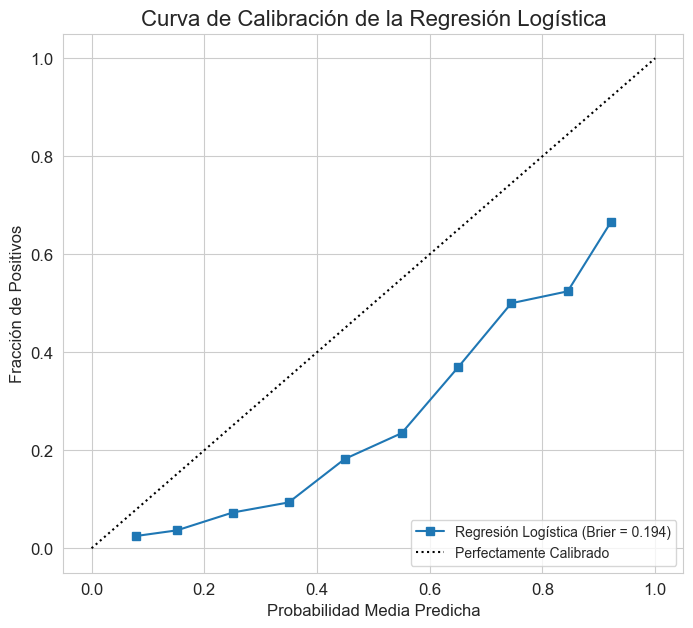

In [20]:
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_proba_logreg_sklearn, n_bins=10)
brier = brier_score_loss(y_test, y_proba_logreg_sklearn)

plt.figure(figsize=(8, 7))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=f'Regresión Logística (Brier = {brier:.3f})')
plt.plot([0, 1], [0, 1], "k:", label="Perfectamente Calibrado")
plt.xlabel('Probabilidad Media Predicha', fontsize=12)
plt.ylabel('Fracción de Positivos', fontsize=12)
plt.title('Curva de Calibración de la Regresión Logística', fontsize=16)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)
plt.show()

### 💡 Interpretación de la Calibración

*   **Brier Score = 0.194.**
*   **El modelo NO está bien calibrado:** la curva queda por debajo de la diagonal, es decir, **sobreestima** la probabilidad de churn. Es el efecto esperado de `class_weight='balanced'`, que infla artificialmente las probabilidades de la clase minoritaria.
*   **Implicación:** las probabilidades sirven para **ordenar** clientes por riesgo, pero no deben leerse como probabilidades reales sin recalibrar (p. ej., con `CalibratedClassifierCV`).

## ✍️ Conclusiones del Baseline y Próximos Pasos

### Hallazgos clave
1.  **Drivers de churn:** `Geography_Germany` (OR 2.28) y `Age` (OR 2.10) son los factores de riesgo más fuertes; `IsActiveMember` (OR 0.60) y ser hombre (OR 0.59) son protectores. `Balance` tiene un efecto positivo moderado.
2.  **Desbalance:** el 20.37% de churn se abordó con `class_weight='balanced'` y se evaluó con métricas adecuadas para clases desbalanceadas (Recall, Precision, F1, AUC, AP).
3.  **Rendimiento:** AUC 0.78, Recall 0.70, Precision 0.39, F1 0.50 en el set de prueba.
4.  **Calibración:** el balanceo de clases provoca probabilidades sobreestimadas (Brier 0.194); útiles para ranking, no como probabilidades absolutas.
5.  **Limitación:** al ser lineal, no captura relaciones no lineales como la de `NumOfProducts` (2 productos = el grupo más estable; 3–4 productos = churn de 83–100%).

### Próximos pasos
*   Probar modelos basados en árboles (Notebook 2), capaces de capturar no linealidades e interacciones.
*   Desde negocio: investigar el churn en Alemania, reactivar clientes inactivos y revisar por qué los clientes con 3–4 productos abandonan.